#header#
##subheader##
**bold**  * *italic* *  ***all bold and italic***

In [1]:
#import packages and dataset
import pandas as pd 
import scipy.stats as stats
import os
import sys
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import norm, cauchy
import numpy as np

df = pd.read_parquet('/Users/laurencadle/Downloads/singlesites.parquet')
df.head(10)
energy = df['Energy'].to_numpy()

In [2]:
#super compressed code!!
from spurs_funcs import *

Gaussian: mu=198.544±0.050, width=1.401±0.055, c=-653.358±28.587, d=174251.763±5649.961


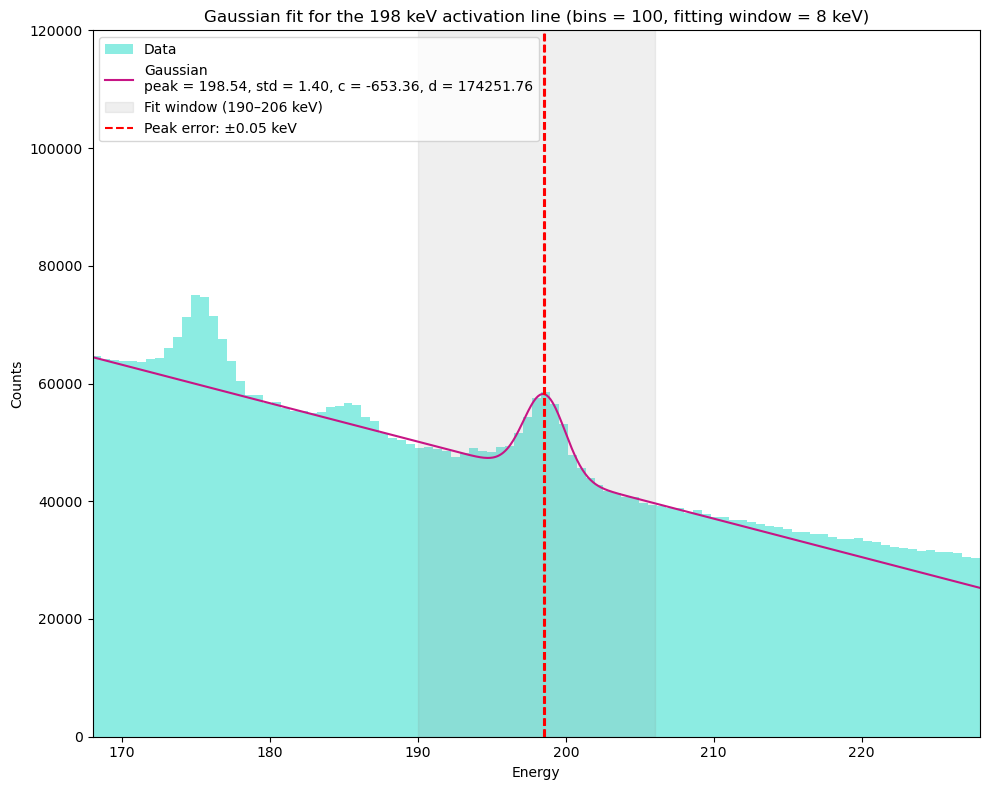

In [42]:
#ten line code!!
line = 198
N = 100
fitting_window = 8

lower_bound, upper_bound, fitted_lower, fitted_upper= get_bounds(line, fitting_window=fitting_window)
counts, bin_edges, bin_width, bin_centers = bin_sorting(N, energy, lower_bound, upper_bound)
slope_val = slope(bin_edges[-1], bin_edges[0], counts[-1], counts[0])
peak_mask = get_masks(fitted_lower, fitted_upper, bin_centers)
popt, pcov, p_err = fit_peak(gaussian_func, line, counts, peak_mask, bin_centers, slope_val, fitted_lower, fitted_upper)
print(f"Gaussian: mu={popt[0]:.3f}±{p_err[0]:.3f}, width={popt[1]:.3f}±{p_err[1]:.3f}, "f"c={popt[2]:.3f}±{p_err[2]:.3f}, d={popt[3]:.3f}±{p_err[3]:.3f}")
x1, fitted_model_g = plot_gaussian(line, N, p_err, counts, bin_edges, popt, lower_bound, upper_bound, fitted_lower, fitted_upper, fitting_window, ylim=(0, 120000))
#574, 1107, 198, 175, 596, 93
#changes to bins: 25, 50, 100, 300, 500
#changes to fitting windows: 5, 8, 10, 20, 30
#ask about how to fix squiggly lines

#mu is the peak position, and this is what i want the error on

In [43]:
print(popt)
print(p_err)
print(popt / p_err)


[ 1.98543940e+02  1.40070804e+00 -6.53358265e+02  1.74251763e+05
  4.79301125e+04]
[4.99924922e-02 5.51335562e-02 2.85867869e+01 5.64996147e+03
 1.96362778e+03]
[3971.475145     25.40572639  -22.85525363   30.84123033   24.40896026]


In [17]:
#p_err/sigma for 438, 300
line = 438
N = 300
print("Gaussian statistics and errors:")

lower_bound, upper_bound, fitted_lower, fitted_upper = get_bounds(line)
counts, bin_edges, bin_width, bin_centers = bin_sorting(N, energy, lower_bound, upper_bound)
slope_val = slope(bin_edges[-1], bin_edges[0], counts[-1], counts[0])
peak_mask = get_masks(fitted_lower, fitted_upper, bin_centers)
popt, pcov, p_err = fit_peak(gaussian_func, line, counts, peak_mask, bin_centers, slope_val, fitted_lower, fitted_upper)
print(f"Gaussian: mu={popt[0]:.3f}±{p_err[0]:.3f}, width={popt[1]:.3f}±{p_err[1]:.3f}, "f"c={popt[2]:.3f}±{p_err[2]:.3f}, d={popt[3]:.3f}±{p_err[3]:.3f}")

print("p_err of peak:", p_err[0]) #peak
print("p_err of sigma:", p_err[1]) #sigma

Gaussian statistics and errors:
Gaussian: mu=439.531±0.108, width=1.490±0.156, c=-7.862±5.263, d=5648.926±2287.140
p_err of peak: 0.10769384201806415
p_err of sigma: 0.15551491290726485


In [18]:
#p_err / c for 438, 500
line = 438
N = 500
print("Gaussian statistics and errors:")

lower_bound, upper_bound, fitted_lower, fitted_upper = get_bounds(line) #inside
counts, bin_edges, bin_width, bin_centers = bin_sorting(N, energy, lower_bound, upper_bound) #outside
slope_val = slope(bin_edges[-1], bin_edges[0], counts[-1], counts[0]) #outside
peak_mask = get_masks(fitted_lower, fitted_upper, bin_centers) #inside
popt, pcov, p_err = fit_peak(gaussian_func, line, counts, peak_mask, bin_centers, slope_val, fitted_lower, fitted_upper) #inside
print(f"Gaussian: mu={popt[0]:.3f}±{p_err[0]:.3f}, width={popt[1]:.3f}±{p_err[1]:.3f}, "f"c={popt[2]:.3f}±{p_err[2]:.3f}, d={popt[3]:.3f}±{p_err[3]:.3f}")

print("p_err of peak:", p_err[0])
print("p_err of sigma:", p_err[1])

Gaussian statistics and errors:
Gaussian: mu=439.536±0.140, width=1.563±0.203, c=-5.715±4.094, d=3816.564±1778.192
p_err of peak: 0.14019344877257978
p_err of sigma: 0.20271157205963103


In [19]:
#find delta c for 300 and 500
c_500 = 5.715
c_300 = -7.862
delta_c = c_500 - c_300
print("delta_c:", delta_c)

#find c +/- 3deltac for 300 
c_300_lower = c_300 - 3 * delta_c
c_300_upper = c_300 + 3 * delta_c
print("c_300_lower:", c_300_lower)
print("c_300_upper:", c_300_upper)

#find c +/- 3deltac for 500
c_500_lower = c_500 - 3 * delta_c
c_500_upper = c_500 + 3 * delta_c
print("c_500_lower:", c_500_lower)
print("c_500_upper:", c_500_upper)

#yes, there is some overlap between the c values

delta_c: 13.577
c_300_lower: -48.593
c_300_upper: 32.869
c_500_lower: -35.016000000000005
c_500_upper: 46.446


In [3]:
#building the pandas df
from spurs_funcs import *
energy = df['Energy'].to_numpy()

#making a list to hold my objects <3
stored_values = []

#step 1: create a lil dictionary of the centroid values from the paper
centroid_vals = {93:93.311, 175:174.956, 198:198.394, 438:438.634, 596:595.847, 1107:1107.016}

#step 32: all the for loops!
for line in [93, 175, 198, 438, 596, 1107]:
    lower_bound, upper_bound, _, _ = get_bounds(line)
    
    for bins in [50, 100, 200, 400]:
        counts, bin_edges, bin_width, bin_centers = bin_sorting(bins, energy, lower_bound, upper_bound)
        slope_val = slope(bin_edges[-1], bin_edges[0], counts[-1], counts[0])
        
        for fitting_window in [3, 4, 5, 8, 10]:
            _, _, fitted_lower, fitted_upper = get_bounds(line, fitting_window=fitting_window)
            peak_mask = get_masks(fitted_lower, fitted_upper, bin_centers)
            popt, pcov, p_err = fit_peak(gaussian_func, line, counts, peak_mask, bin_centers, slope_val, fitted_lower, fitted_upper)
            snr_val = snr(popt, counts, bin_centers)
            
            row = {
                "line": line,
                "bins": bins, 
                "fitting_window": fitting_window, 
                "bin_width": bin_width, 
                "mu": popt[0],
                "sigma": popt[1], 
                "c": popt[2], 
                "d": popt[3], 
                "A": popt[4], 
                "mu_err": p_err[0], 
                "sigma_err": p_err[1],
                "c_err": p_err[2],
                "d_err": p_err[3],
                "A_err": p_err[4],
                "exact_mu": centroid_vals[line],
                "deviation_in_centroid": (popt[0] - centroid_vals[line]) / p_err[0], 
                "A_over_A_err": popt[4] / p_err[4], 
                "snr": snr_val
            }
            #storing all 80 rows into my empty list
            stored_values.append(row)
            
#step 4: now i need to put them in a df
stored_values_df = pd.DataFrame(stored_values)

/Users/laurencadle/spurs_2026/spurs_funcs.py:49: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(gaussian_func, bin_centers[peak_mask], counts[peak_mask], p0=p0_gauss, bounds=([fitted_lower, 1, 3*slope_val, 0, -500], [fitted_upper, 10, 0, 1e6, np.inf]), maxfev=50000)


In [4]:
stored_values_df.to_csv("/Users/laurencadle/spurs_2026/stored_values.csv", index=False)
stored_values_df.head(10)

,line,bins,fitting_window,bin_width,mu,sigma,c,d,A,mu_err,sigma_err,c_err,d_err,A_err,exact_mu,deviation_in_centroid,A_over_A_err,snr
0,93,50,3,1.224490,92.863994,1.994217,-1438.300000,386488.230611,236643.985623,inf,inf,inf,inf,inf,93.311,-0.000000,0.000000,142.081015
1,93,50,4,1.224490,92.854531,1.827730,-1247.486794,373561.983257,196189.457510,0.169455,0.281346,710.643412,6.744738e+04,4.953958e+04,93.311,-2.693753,3.960256,122.325174
2,93,50,5,1.224490,92.908643,1.000000,-1041.179225,370014.979814,23244.309857,2.478312,2.488218,2029.480694,1.890654e+05,6.432902e+04,93.311,-0.162351,0.361335,67.726910
3,93,50,8,1.224490,92.843308,1.000000,-452.712519,310949.967166,8250.904246,6.867135,6.826098,1148.829383,1.071005e+05,5.778961e+04,93.311,-0.068106,0.142775,81.573439
4,93,50,10,1.224490,92.823157,1.000000,-280.561689,291147.110985,13476.771684,3.701261,3.650249,676.107983,6.308331e+04,4.860903e+04,93.311,-0.131804,0.277248,82.327693
5,93,100,3,0.606061,92.872794,3.518926,-657.148581,149538.636607,529194.981157,0.522352,2.704231,2154.041178,2.433278e+05,1.126892e+06,93.311,-0.838911,0.469606,526.366288
6,93,100,4,0.606061,92.850354,1.930404,-657.150000,187350.094126,108685.311282,0.080846,0.148046,192.454679,1.837570e+04,1.518865e+04,93.311,-5.697822,7.155692,132.576322
7,93,100,5,0.606061,92.712911,1.911406,-267.302700,151320.158576,107131.095746,0.065576,0.093743,107.119231,1.018157e+04,7.706308e+03,93.311,-9.120532,13.901741,131.777911
8,93,100,8,0.606061,92.648061,1.904884,-125.257493,138300.318828,105996.217500,0.056328,0.065187,44.865203,4.209939e+03,4.108097e+03,93.311,-11.769357,25.801780,130.680749
9,93,100,10,0.606061,92.624433,1.955450,-84.787189,134153.120201,110135.755214,0.062013,0.069480,36.430434,3.415209e+03,4.197670e+03,93.311,-11.071384,26.237353,135.155575


In [24]:
#smallest error in mu 
for line in stored_values_df['line'].unique():
    smallest_error = stored_values_df[stored_values_df['line'] == line]['mu_err'].min()
    print(f"line {line}: smallest error in mu (peak) = {smallest_error}")

print() 

#smallest deivation in centroid
for line in stored_values_df['line'].unique():
    smallest_deviation = stored_values_df[(stored_values_df['line'] == line) & (stored_values_df['deviation_in_centroid'] != 0)]['deviation_in_centroid'].min()
    print(f"line {line}: smallest deviation in centroid = {smallest_deviation}")

line 175: smallest error in mu (peak) = 0.030062178376756267
line 198: smallest error in mu (peak) = 0.013598412626985492
line 438: smallest error in mu (peak) = 0.06729645918030627
line 596: smallest error in mu (peak) = 0.04188609194678381

line 175: smallest deviation in centroid = 4.618521548637417
line 198: smallest deviation in centroid = 2.2249758527722308
line 438: smallest deviation in centroid = 1.0719124575060974
line 596: smallest deviation in centroid = 0.8147572690553623


Gaussian: mu=175.393±0.030, width=1.295±0.036, c=-388.968±20.195, d=98321.312±3518.185


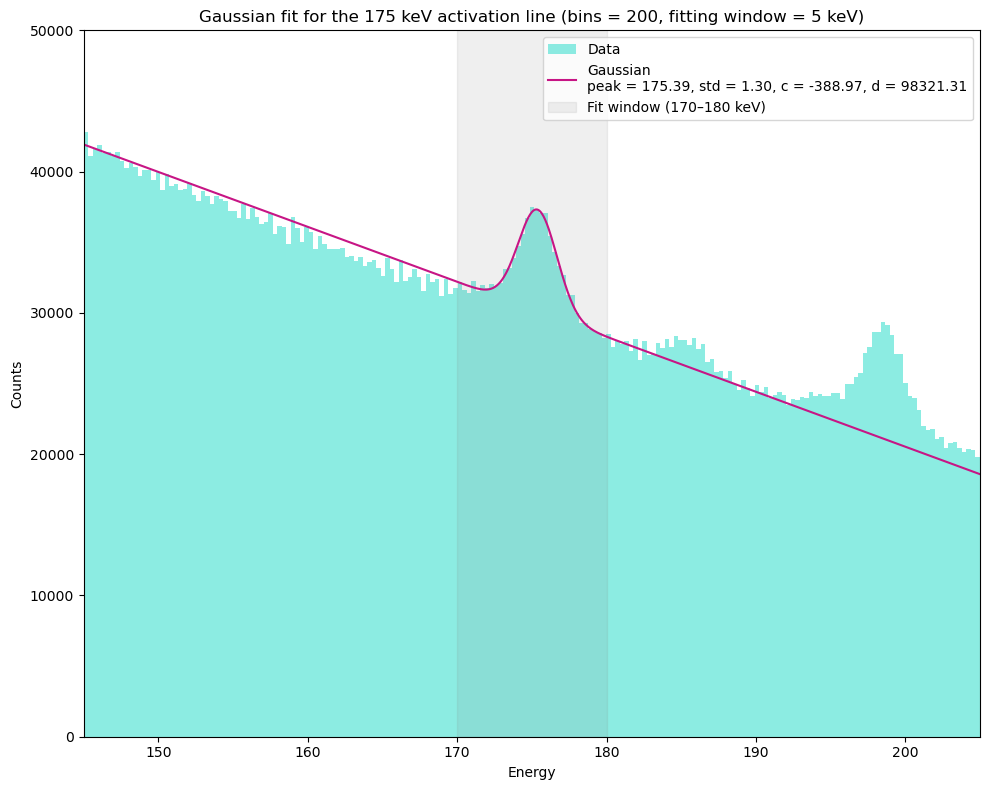

In [ ]:
#super compressed code!! 93 and 175
from spurs_2026.spurs_funcs import *
energy = df['Energy'].to_numpy()

#ten line code!!
line = 175
N = 200
fitting_window = 5

lower_bound, upper_bound, fitted_lower, fitted_upper = get_bounds(line, 30, fitting_window)
counts, bin_edges, bin_width, bin_centers = bin_sorting(N, energy, lower_bound, upper_bound)
slope_val = slope(bin_edges[-1], bin_edges[0], counts[-1], counts[0])
peak_mask = get_masks(fitted_lower, fitted_upper, bin_centers)
popt, pcov, p_err = fit_peak(quadratic_func, line, counts, peak_mask, bin_centers, slope_val, fitted_lower, fitted_upper)
print(f"Quadratic: mu={popt[0]:.3f}±{p_err[0]:.3f}, width={popt[1]:.3f}±{p_err[1]:.3f}, "f"c={popt[2]:.3f}±{p_err[2]:.3f}, d={popt[3]:.3f}±{p_err[3]:.3f}")
x1, fitted_model_g = plot_gaussian(line, N, p_err, counts, bin_edges, popt, lower_bound, upper_bound, fitted_lower, fitted_upper, fitting_window, ylim=(0, 50000))

slope_val: -0.06666666666666667 c bounds: -0.2 0
Gaussian: mu=511.843±0.051, width=1.863±0.059, c=-0.200±0.120, d=125.855±61.375


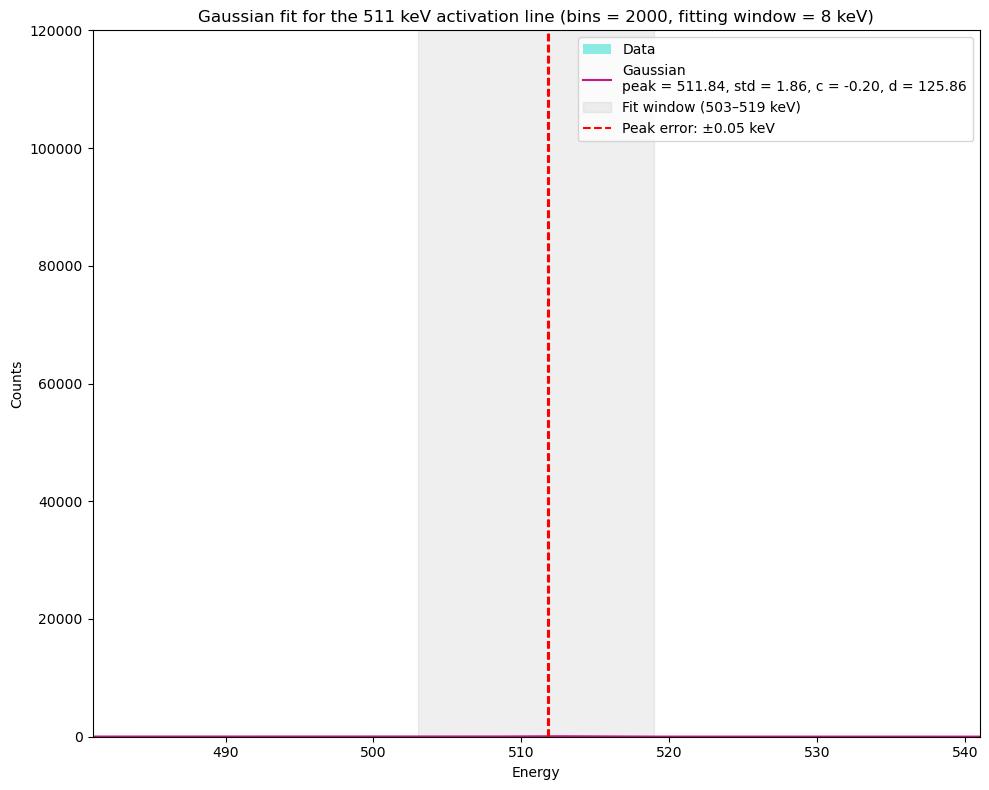

Detector 1, 511 keV: SNR = 626.17


In [47]:
#snr counts!!
line = 511      
N = 2000
detector = 1

from spurs_funcs import *
energy = df[df['Detector ID'] == detector]['Energy'].to_numpy()

def snr(popt_g, counts, bin_width):
    mu, sigma, c, d, A = popt_g
    total_counts = np.sum(counts)
    lower = mu - 1.4*sigma
    upper = mu + 1.4*sigma
    h = upper - lower
    S = (norm.cdf(upper, mu, sigma) - norm.cdf(lower, mu, sigma)) * A * total_counts * bin_width
    B = 1/2 * ((c*lower + d) + (c*upper + d)) * h
    return S / np.sqrt(S + B)

lower_bound, upper_bound, fitted_lower, fitted_upper = get_bounds(line, fitting_window=fitting_window)
counts, bin_edges, bin_width, bin_centers = bin_sorting(N, energy, lower_bound, upper_bound)
slope_val = slope(bin_edges[-1], bin_edges[0], counts[-1], counts[0])
slope_val = -abs(slope_val)
print("slope_val:", slope_val, "c bounds:", 3*slope_val, 0)
peak_mask = get_masks(fitted_lower, fitted_upper, bin_centers)
popt, pcov, p_err = fit_peak(gaussian_func, line, counts, peak_mask, bin_centers, slope_val, fitted_lower, fitted_upper)
print(f"Gaussian: mu={popt[0]:.3f}±{p_err[0]:.3f}, width={popt[1]:.3f}±{p_err[1]:.3f}, "f"c={popt[2]:.3f}±{p_err[2]:.3f}, d={popt[3]:.3f}±{p_err[3]:.3f}")
x1, fitted_model_g = plot_gaussian(line, N, p_err, counts, bin_edges, popt, lower_bound, upper_bound, fitted_lower, fitted_upper, fitting_window, ylim=(0, 120000))

snr_val = snr(popt, counts, bin_width)
print(f"Detector {detector}, {line} keV: SNR = {snr_val:.2f}")